# LendMind

### 1) Importing Libraries

In [ ]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install matplotlib==3.9.3

In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 2) Read & Understand The Data

In [2]:
all_data = pd.read_csv(r"..\data\archive\loan.csv")

In [3]:
all_data.shape

(2260668, 145)

--> select the output ('loan_status')

In [4]:
all_data = all_data[all_data['loan_status'].isin(['Fully Paid', 'Charged Off'])]
all_data['loan_status'] = all_data['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
all_data.shape

(1303607, 145)

A) We will take a random sample from the dataset (all_data), for example 100k rows:

frac = 100000 / 1303607 = 0.07671

In [5]:
df = all_data.sample(frac= 0.07671, random_state= 42)
df.shape

(100000, 145)

In [6]:
df.sample(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
811079,NaN,NaN,15000,15000,15000.0,36 months,5.32,451.73,A,A1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2043986,NaN,NaN,18000,18000,18000.0,36 months,8.90,571.56,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1835540,NaN,NaN,6000,6000,5975.0,36 months,12.12,199.63,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2096363,NaN,NaN,9000,9000,9000.0,36 months,8.90,285.78,A,A5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2045068,NaN,NaN,7000,7000,7000.0,36 months,10.99,229.14,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


B) dealing with Null values

In [7]:
df = df.loc[:, df.isnull().mean()<0.4]
df.shape

(100000, 87)

In [8]:
df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
1881581,10000,10000,10000.0,36 months,14.31,343.29,C,C4,Service Car Detail,10+ years,...,100.0,0.0,0.0,145200.0,22578.0,7400.0,5000.0,N,Cash,N
794624,15000,15000,15000.0,36 months,17.27,536.81,D,D3,Nanny,3 years,...,66.7,1.0,0.0,71318.0,54302.0,8600.0,55718.0,N,Cash,Y
2078633,14400,14400,14400.0,36 months,11.99,478.22,B,B3,pharmacy tech,10+ years,...,100.0,0.0,0.0,177470.0,30637.0,11500.0,26345.0,N,Cash,N
1933558,4475,4475,4475.0,36 months,18.24,162.33,D,D5,Respiratory Therapist,2 years,...,100.0,0.0,0.0,58639.0,57061.0,1400.0,57239.0,N,Cash,N
1277986,15000,15000,15000.0,36 months,7.89,469.29,A,A5,Uber (taxi driver),1 year,...,50.0,0.0,0.0,70602.0,35942.0,28000.0,30102.0,N,Cash,N


C) Remove columns where all cells have the same value (Zero Variance Filter)

In [9]:
df = df.loc[:, df.nunique()>1]
df.shape

(100000, 82)

In [10]:
df.sample(5)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag
1645365,33750,33750,33750.0,60 months,13.49,776.41,C,C2,Service consultant,5 years,...,100.0,0.0,1.0,0.0,62530.0,29664.0,14100.0,33430.0,Cash,N
1007526,16000,16000,16000.0,60 months,15.41,384.10,D,D1,Service Division Specialist,10+ years,...,100.0,80.0,0.0,0.0,44300.0,38815.0,27300.0,15000.0,Cash,N
1797911,3600,3600,3600.0,36 months,18.75,131.51,D,D3,Presbyterian Hospital,8 years,...,100.0,60.0,1.0,0.0,37808.0,32522.0,2200.0,30308.0,Cash,N
1568729,7000,7000,7000.0,36 months,12.62,234.58,C,C1,Departmental Technician,7 years,...,76.5,100.0,0.0,2.0,250565.0,38655.0,2800.0,34596.0,Cash,N
1563253,19800,19800,19800.0,60 months,30.94,652.08,G,G4,NURSING ASSISTANT,1 year,...,97.4,20.0,0.0,0.0,75950.0,36605.0,23200.0,32750.0,Cash,N


D) High Cardinality Filter

In [11]:
string_columns = df.select_dtypes(include='object').columns
string_df = df[string_columns]
hated_columns = string_df.loc[:, (string_df.nunique() > 50)].columns
df = df.drop(columns=hated_columns)
df.shape

(100000, 75)

E) Multicollinearity Filter

In [12]:
corr_matrix = df.select_dtypes(include=['number']).corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.95)]
df = df.drop(columns=to_drop)
df.shape

(100000, 66)

['recoveries', 'last_pymnt_amnt', 'total_pymnt', 'loan_amnt', 'debt_settlement_flag_Y', 'total_rec_int', 'int_rate', 'term_ 60 months', 'total_rec_late_fee', 'dti', 'bc_open_to_buy', 'avg_cur_bal', 'revol_bal', 'bc_util', 'annual_inc']


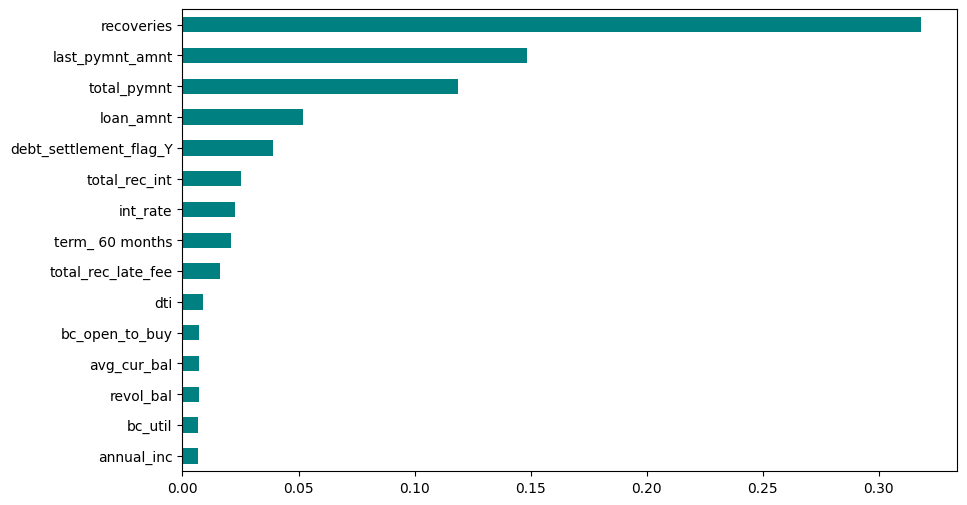

In [ ]:
'''
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_encoded = pd.get_dummies(X, drop_first=True)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_encoded, y)

importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_15_features = importances.sort_values(ascending=False).head(15).index.tolist()

print(top_15_features)

plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.show()
'''

F) Preventing Data Leakage

In [14]:
leakage_columns = [
    'recoveries', 'collection_recovery_fee', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt',
    'out_prncp', 'out_prncp_inv', 'debt_settlement_flag' 
]

cols_to_drop = [col for col in leakage_columns if col in df.columns]
df_safe = df.drop(columns=cols_to_drop)
print(df_safe.shape)
print(f"cols_to_drop:\n{cols_to_drop}")

(100000, 60)
cols_to_drop:
['recoveries', 'total_pymnt', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt', 'debt_settlement_flag']


✅ The top 15 columns were successfully extracted, and they are:
1- int_rate
2- dti
3- revol_util
4- annual_inc
5- loan_amnt
6- mo_sin_old_rev_tl_op
7- revol_bal
8- avg_cur_bal
9- bc_open_to_buy
10- bc_util
11- tot_cur_bal
12- total_bc_limit
13- mo_sin_old_il_acct
14- total_bal_ex_mort
15- total_rev_hi_lim
----------------------------------------
Final data size (15 features + 1 goal): (100000, 16)


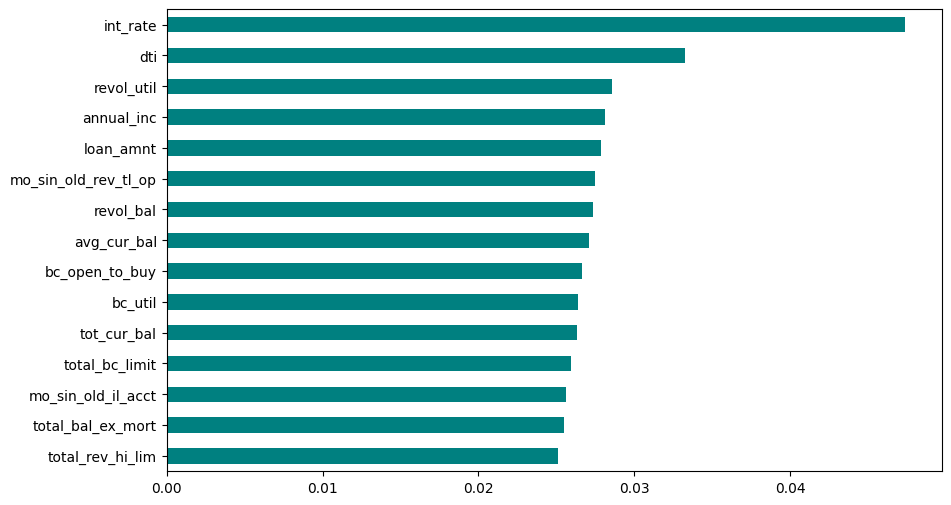

In [15]:
from sklearn.ensemble import RandomForestClassifier

X = df_safe.drop(columns=['loan_status'])
y = df_safe['loan_status']
X_encoded = pd.get_dummies(X, drop_first=True).fillna(-999)


rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_encoded, y)

importances = pd.Series(rf_selector.feature_importances_, index=X_encoded.columns)
top_15_features = importances.sort_values(ascending=False).head(15).index.tolist()

df_final = X_encoded[top_15_features].copy()
df_final['loan_status'] = y


print("✅ The top 15 columns were successfully extracted, and they are:")
for i, feature in enumerate(top_15_features, 1):
    print(f"{i}- {feature}")

print("-" * 40)
print("Final data size (15 features + 1 goal):", df_final.shape)


plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.show()


In [16]:
df_final.to_csv(r'..\data\cleaned_data.csv', index=False)
print("Cleaned data successfully saved!")

Cleaned data successfully saved!
